In [11]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np
import torch

In [12]:
image = 'roadsigns.png'

im = cv2.imread(image)

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [14]:
read = easyocr.Reader(['en'],gpu=device)

text_ = read.readtext(im)

In [4]:
for item in text_:
    #print(item)
    bbox,text,score=item

    cv2.rectangle(im, bbox[0],bbox[2],(0,255,0),3)
    cv2.putText(im,text,bbox[0],cv2.FONT_HERSHEY_COMPLEX,1,(0,255,0),1)

<function matplotlib.pyplot.show(close=None, block=None)>

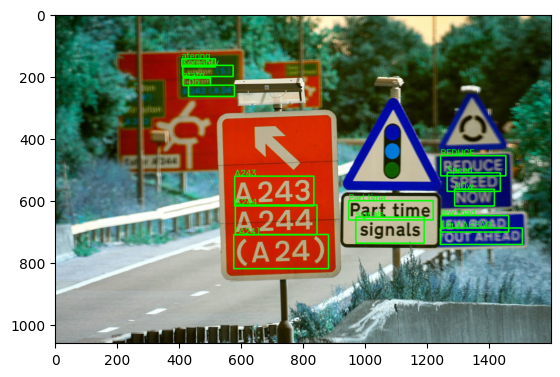

In [5]:
plt.imshow(im)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

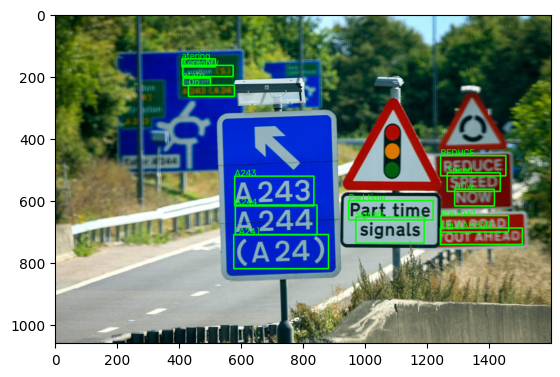

In [6]:
plt.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

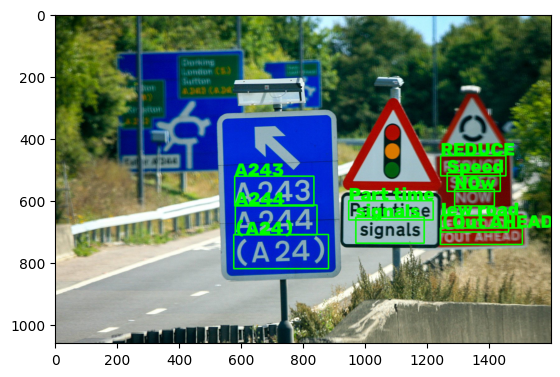

In [15]:
threshold = np.float64(0.05)
for item in text_:
    bbox,text,score=item

    if score > threshold:
        cv2.rectangle(im, bbox[0],bbox[2],(0,255,0),3)
        cv2.putText(im,text,bbox[0],cv2.FONT_HERSHEY_COMPLEX,2,(0,255,0),2)

plt.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB))
plt.show